In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import random
import math
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [4]:
train_df = pd.read_csv("train.csv")
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43957 entries, 0 to 43956
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              43957 non-null  int64 
 1   workclass        41459 non-null  object
 2   fnlwgt           43957 non-null  int64 
 3   education        43957 non-null  object
 4   educational-num  43957 non-null  int64 
 5   marital-status   43957 non-null  object
 6   occupation       41451 non-null  object
 7   relationship     43957 non-null  object
 8   race             43957 non-null  object
 9   gender           43957 non-null  object
 10  capital-gain     43957 non-null  int64 
 11  capital-loss     43957 non-null  int64 
 12  hours-per-week   43957 non-null  int64 
 13  native-country   43194 non-null  object
 14  income_>50K      43957 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 5.0+ MB


In [5]:
train_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income_>50K
0,67,Private,366425,Doctorate,16,Divorced,Exec-managerial,Not-in-family,White,Male,99999,0,60,United-States,1
1,17,Private,244602,12th,8,Never-married,Other-service,Own-child,White,Male,0,0,15,United-States,0
2,31,Private,174201,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,1
3,58,State-gov,110199,7th-8th,4,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,0
4,25,State-gov,149248,Some-college,10,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,United-States,0


In [9]:
train_df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,income_>50K
count,43957.000000,4.395700e+04,43957.000000,43957.000000,43957.000000,43957.000000,43957.000000
mean,38.617149,1.896730e+05,10.074118,1093.559797,88.246491,40.407694,0.239279
std,13.734401,1.058215e+05,2.575092,7570.536063,404.588410,12.400303,0.426648
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.174960e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781000e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376710e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [11]:
test_df = pd.read_csv("test.csv")
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899 entries, 0 to 898
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              899 non-null    int64 
 1   workclass        899 non-null    object
 2   fnlwgt           899 non-null    int64 
 3   education        899 non-null    object
 4   educational-num  899 non-null    int64 
 5   marital-status   899 non-null    object
 6   occupation       899 non-null    object
 7   relationship     899 non-null    object
 8   race             899 non-null    object
 9   gender           899 non-null    object
 10  capital-gain     899 non-null    int64 
 11  capital-loss     899 non-null    int64 
 12  hours-per-week   899 non-null    int64 
 13  native-country   899 non-null    object
dtypes: int64(6), object(8)
memory usage: 98.5+ KB


In [13]:
test_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
0,39,Self-emp-not-inc,327120,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,Portugal
1,32,Private,123253,Assoc-acdm,12,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,42,United-States
2,47,Private,232628,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,Black,Male,0,0,40,United-States
3,19,Private,374262,12th,8,Never-married,Handlers-cleaners,Own-child,White,Male,0,0,20,United-States
4,46,Self-emp-not-inc,311231,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,40,United-States


In [15]:
# filter native country for only US results
# get rid of capital gain, capital loss, and fnlwgt columns
# fill any null values with "unknown" (safety net, although there do not seem to be any missing)
def clean_data(df):
    df = df[df["native-country"] == "United-States"]
    
    df = df.drop(columns=["fnlwgt", "capital-gain", "capital-loss"])
    
    df["workclass"] = df["workclass"].fillna("Unknown")
    df["occupation"] = df["occupation"].fillna("Unknown")
    
    return df

train_df = clean_data(train_df)
test_df = clean_data(test_df)


In [19]:
train_df.head()
train_df.describe()
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39429 entries, 0 to 43956
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              39429 non-null  int64 
 1   workclass        39429 non-null  object
 2   education        39429 non-null  object
 3   educational-num  39429 non-null  int64 
 4   marital-status   39429 non-null  object
 5   occupation       39429 non-null  object
 6   relationship     39429 non-null  object
 7   race             39429 non-null  object
 8   gender           39429 non-null  object
 9   hours-per-week   39429 non-null  int64 
 10  native-country   39429 non-null  object
 11  income_>50K      39429 non-null  int64 
dtypes: int64(4), object(8)
memory usage: 3.9+ MB


In [17]:
test_df.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,hours-per-week,native-country
1,32,Private,Assoc-acdm,12,Married-civ-spouse,Craft-repair,Husband,White,Male,42,United-States
2,47,Private,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,Black,Male,40,United-States
3,19,Private,12th,8,Never-married,Handlers-cleaners,Own-child,White,Male,20,United-States
4,46,Self-emp-not-inc,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,40,United-States
5,45,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,50,United-States


In [19]:
# encoding 
train_df_encoding = pd.get_dummies(train_df, columns= ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country'], dtype=int)
test_df_encoding = pd.get_dummies(test_df, columns= ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country'], dtype=int)
train_df_encoding.head()
test_df_encoding.head()
train_df_encoding.info()
test_df_encoding.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39429 entries, 0 to 43956
Data columns (total 65 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   age                                   39429 non-null  int64
 1   educational-num                       39429 non-null  int64
 2   hours-per-week                        39429 non-null  int64
 3   income_>50K                           39429 non-null  int64
 4   workclass_Federal-gov                 39429 non-null  int32
 5   workclass_Local-gov                   39429 non-null  int32
 6   workclass_Never-worked                39429 non-null  int32
 7   workclass_Private                     39429 non-null  int32
 8   workclass_Self-emp-inc                39429 non-null  int32
 9   workclass_Self-emp-not-inc            39429 non-null  int32
 10  workclass_State-gov                   39429 non-null  int32
 11  workclass_Unknown                     39429 no

In [21]:
train_df_encoding, test_df_encoding = train_df_encoding.align(
    test_df_encoding, join='left', axis=1, fill_value=0)

In [23]:
set(train_df_encoding.columns)==set(test_df_encoding.columns)

True

In [25]:
numeric_cols = ['age', 'hours-per-week']
scaler = StandardScaler()
# fitting the scaler only to the train data
scaler.fit(train_df[numeric_cols])
# transforming both train and test
train_df_encoding[numeric_cols] = scaler.transform(train_df_encoding[numeric_cols])
test_df_encoding[numeric_cols] = scaler.transform(test_df_encoding[numeric_cols])
# print
print("Scaled train head:", train_df_encoding[numeric_cols].head())
print("Scaled train describe:", train_df_encoding[numeric_cols].describe())

Scaled train head:         age  hours-per-week
0  2.048918        1.568702
1 -1.568306       -2.037764
2 -0.555483       -0.034172
3  1.397817       -0.034172
4 -0.989550       -0.034172
Scaled train describe:                 age  hours-per-week
count  3.942900e+04    3.942900e+04
mean  -1.083051e-16   -3.243747e-17
std    1.000013e+00    1.000013e+00
min   -1.568306e+00   -3.159776e+00
25%   -7.725164e-01   -3.417220e-02
50%   -1.214163e-01   -3.417220e-02
75%    6.743728e-01    3.665463e-01
max    3.712840e+00    4.694306e+00


In [27]:
# defining features and target for education
EDU_FEATURES = [col for col in train_df_encoding.columns
                if any(col.startswith(p) for p in
                      ['age', 'workclass', 'occupation', 'income',
                'marital', 'relationship', 'race', 'gender', 'hours'])]
EDU_TARGET = 'educational-num'

# splitting the data
X_edu = train_df_encoding[EDU_FEATURES]
y_edu = train_df_encoding[EDU_TARGET]

X_edu_train, X_edu_dev, y_edu_train, y_edu_dev = train_test_split(
    X_edu, y_edu, test_size=0.15, random_state=42)

print(X_edu_train.shape)
print(X_edu_dev.shape)

(33514, 47)
(5915, 47)


In [29]:
bins = [0, 8, 12, 14, 17]
labels = [0, 1, 2, 3]  # 0=Low, 1=HS-level, 2=Some-college, 3=Advanced

y_edu_train_binned = pd.cut(y_edu_train, bins=bins, labels=labels).astype(int)
y_edu_dev_binned = pd.cut(y_edu_dev, bins=bins, labels=labels).astype(int)


In [31]:
# Model selection and prediction 

# Decision Tree
decision_tree= DecisionTreeClassifier(random_state=42, max_depth=10)

# fitting the classifier
decision_tree.fit(X_edu_train,y_edu_train_binned)

# making predictions
edu_y_prediction = decision_tree.predict(X_edu_dev)
edu_train_score = decision_tree.score(X_edu_train, y_edu_train_binned)
edu_dev_score = decision_tree.score(X_edu_dev, y_edu_dev_binned)
precision = precision_score(y_edu_dev_binned, edu_y_prediction,average='micro')
recall = recall_score(y_edu_dev_binned, edu_y_prediction, average='micro')

print(edu_y_prediction,edu_train_score,edu_dev_score, precision, recall)
print(classification_report(y_edu_dev_binned, edu_y_prediction, 
                            target_names = ['Low', 'HS-level', 'Some-college', 'Advanced']))


[1 2 1 ... 1 1 1] 0.7416900399832905 0.7144547759932375 0.7144547759932375 0.7144547759932375
              precision    recall  f1-score   support

         Low       0.74      0.19      0.30       705
    HS-level       0.73      0.91      0.81      3702
Some-college       0.65      0.49      0.56      1334
    Advanced       0.63      0.33      0.43       174

    accuracy                           0.71      5915
   macro avg       0.69      0.48      0.52      5915
weighted avg       0.71      0.71      0.68      5915



In [33]:
# Random Forest
rfedu = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# fitting the classifier
rfedu.fit(X_edu_train, y_edu_train_binned)

# making predictions
edu_y_prediction_rfedu = rfedu.predict(X_edu_dev)
edu_train_score_rfedu = rfedu.score(X_edu_train, y_edu_train_binned)
edu_dev_score_rfedu = rfedu.score(X_edu_dev, y_edu_dev_binned)
precision_rfedu = precision_score(y_edu_dev_binned, edu_y_prediction_rfedu, average='micro')
recall_rfedu = recall_score(y_edu_dev_binned, edu_y_prediction_rfedu, average='micro')

print(edu_y_prediction_rfedu, edu_train_score_rfedu, edu_dev_score_rfedu, precision_rfedu, recall_rfedu)
print(classification_report(
    y_edu_dev_binned,
    edu_y_prediction_rfedu,
    target_names=['Low', 'HS-level', 'Some-college', 'Advanced']
))

[1 2 1 ... 1 1 1] 0.7288297427940562 0.7120879120879121 0.7120879120879121 0.7120879120879121
              precision    recall  f1-score   support

         Low       0.92      0.15      0.26       705
    HS-level       0.72      0.94      0.82      3702
Some-college       0.65      0.44      0.52      1334
    Advanced       0.75      0.16      0.26       174

    accuracy                           0.71      5915
   macro avg       0.76      0.42      0.47      5915
weighted avg       0.73      0.71      0.67      5915



MSE:      3.7262
R2:       0.3773
Accuracy: 0.6803


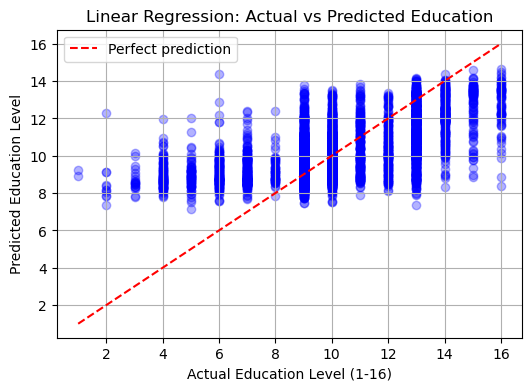

In [34]:
lr_edu = LinearRegression()
lr_edu.fit(X_edu_train, y_edu_train)

# predictions
y_edu_pred = lr_edu.predict(X_edu_dev)

y_edu_pred_binned = pd.cut(y_edu_pred, bins=bins, labels=labels).astype(int)

# scores
mse = mean_squared_error(y_edu_dev, y_edu_pred)
r2 = r2_score(y_edu_dev, y_edu_pred)
accuracy = accuracy_score(y_edu_dev_binned, y_edu_pred_binned)

print(f"MSE:      {mse:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Accuracy: {accuracy:.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(y_edu_dev, y_edu_pred, alpha=0.3, color='blue')
plt.plot([1, 16], [1, 16], color='red', linestyle='--', label='Perfect prediction')
plt.xlabel("Actual Education Level (1-16)")
plt.ylabel("Predicted Education Level")
plt.title("Linear Regression: Actual vs Predicted Education")
plt.legend()
plt.grid()
plt.show()

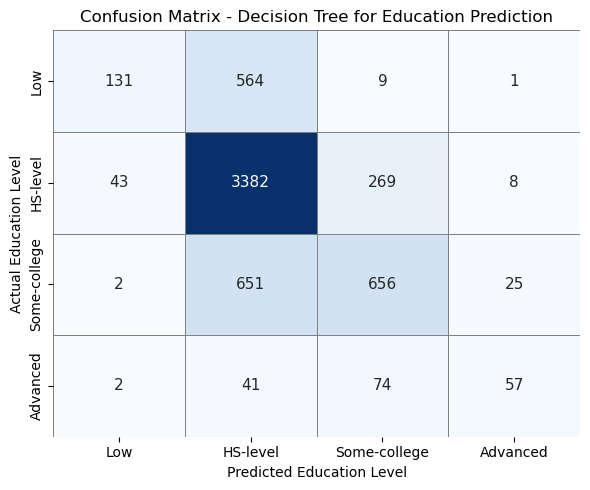

In [77]:
# confusion matrix for education decision tree
cm_education = confusion_matrix(y_edu_dev_binned, edu_y_prediction)
labels = ['Low', 'HS-level', 'Some-college', 'Advanced']

# plot
plt.figure(figsize=(6,5))
sns.heatmap(cm_education, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=labels, yticklabels=labels, linewidths=0.5, linecolor='gray', annot_kws={"size": 11})

plt.xlabel("Predicted Education Level")
plt.ylabel("Actual Education Level")
plt.title("Confusion Matrix - Decision Tree for Education Prediction")

plt.tight_layout()
plt.show()

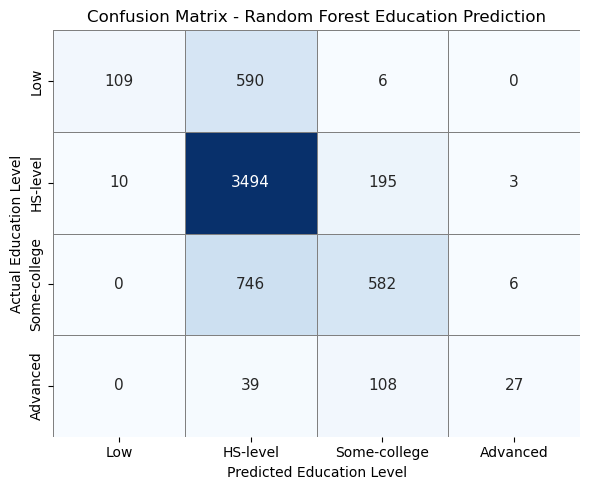

In [67]:
# confusion matrix for education forest
cm_edu = confusion_matrix(y_edu_dev_binned, edu_y_prediction_rfedu)

labels = ['Low', 'HS-level', 'Some-college', 'Advanced']

plt.figure(figsize=(6,5))
sns.heatmap(cm_edu, annot=True, fmt='d', cbar=False,
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            linewidths=0.5, linecolor='gray',
            annot_kws={"size": 11})

plt.xlabel("Predicted Education Level")
plt.ylabel("Actual Education Level")
plt.title("Confusion Matrix - Random Forest Education Prediction")
plt.tight_layout()
plt.show()

In [ ]:
#confusion matrix for random forest
